# CatBoost Classifier - PS-S06E09: Electric Vehicle Purchases

This notebook trains a **CatBoost Classifier** model for Kaggle Playground Series Season 6 Episode 9, predicting the binary target `Will_Buy_EV` (`Yes` / `No`).

Key features:
* **Shared Utilities**: Leverages `ExperimentSetup`, `FeatureFactory`, and `ModelVisualizer`.
* **SQLite-Backed Optuna Persistence**: Hyperparameters tuned via Optuna with persistent SQLite storage (`catboost_study.db`).
* **Fold Cache Pattern**: Features engineered once per fold and cached for fast Optuna evaluation.
* **Multi-Seed Ensembling**: Models evaluated across 5 stratified folds and multiple random seeds.
* **Prediction Export**: Probabilities saved for downstream model ensembling and blending.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import catboost as cb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e09_experiment_setup import ExperimentSetup
from ps_s06e09_feature_engineering import FeatureFactory
from ps_s06e09_model_visualizer import ModelVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='CatBoost',
    use_gpu=True,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'Will_Buy_EV'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66         92,887.000            23.400                     2   
1   1   38         30,000.000             5.000                     1   
2   2   26         94,389.000            36.800                     1   
3   3   66         73,580.000            23.700                     2   
4   4   54         57,898.000            50.800                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                        1.000    Male  Suburban            Sedan   
1                        4

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'ev_ratios',
    'charging_accessibility',
    'financial_incentives',
    'range_anxiety_interactions',
    'buyer_readiness_score',
    'income_age_benchmarks',
    'missing_flags',
    'group_aggregations',
]

ff = FeatureFactory(strategies=fe_strategies, verbose=True)
X = ff.fit_transform(training_df)
y = training_df[TARGET].map({'Yes': 1, 'No': 0})

X_test = ff.transform(test_df)

# True nominal categories passed to CatBoost cat_features
cat_cols = ['Gender', 'City_Type', 'Current_Car_Type']
for c in cat_cols:
    if c in X.columns:
        X[c] = X[c].astype(str)
        X_test[c] = X_test[c].astype(str)

# Convert ordinal categoricals to numeric floats for exact split thresholding
ordinal_map = {
    'Range_Anxiety_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Home_Charging_Possible': {'No': 0, 'Yes': 1},
    'Subsidy_Available': {'No': 0, 'Yes': 1}
}
for col, mapping in ordinal_map.items():
    if col in X.columns:
        X[col] = X[col].astype(str).map(mapping).fillna(0).astype(float)
        X_test[col] = X_test[col].astype(str).map(mapping).fillna(0).astype(float)

print(f'Nominal Categorical features for CatBoost: {cat_cols}')
print(f'Engineered Train shape: {X.shape}')
print(f'Engineered Test shape:  {X_test.shape}')

  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, income_age_benchmarks, missing_flags, group_aggregations
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding EV ratio features...
  -> Adding charging accessibility features...
  -> Adding financial incentive features...
  -> Adding range anxiety interaction features...
  -> Adding buyer readiness score features...
  -> Adding income and age benchmark features...
  -> Adding group aggregation features...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, income_age_benchmarks, missing_flags, group_aggregations
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding EV ratio features...
  -> Adding charging accessibility features...
  -> Adding fin

## 4. Hyperparameter Tuning (Optuna + SQLite Storage)

In [5]:
optuna_filename = 'optuna_params_catboost.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print('Starting Optuna hyperparameter optimization for CatBoost...')

    # Fold Cache Pattern
    skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_cache = []
    for tr_idx, val_idx in skf_cv.split(X, y):
        fold_cache.append((
            X.iloc[tr_idx].copy(),
            X.iloc[val_idx].copy(),
            y.iloc[tr_idx].copy(),
            y.iloc[val_idx].copy()
        ))

    def objective(trial):
        params = {
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'metric_period': 5,
            'task_type': 'GPU' if setup.use_gpu() else 'CPU',
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
            'depth': trial.suggest_int('depth', 4, 8),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'border_count': trial.suggest_int('border_count', 128, 254),
            'iterations': 2500,
            'random_seed': seed,
            'verbose': False
        }

        scores = []
        for fold_idx, (X_tr, X_val, y_tr, y_val) in enumerate(fold_cache):
            model = cb.CatBoostClassifier(**params, cat_features=cat_cols, early_stopping_rounds=100)
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
            val_preds = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, val_preds)
            scores.append(score)

        return np.mean(scores)

    sampler = optuna.samplers.TPESampler(multivariate=True, seed=seed)
    study = optuna.create_study(
        study_name='catboost_tuning_v13',
        storage='sqlite:///catboost_study.db',
        pruner=optuna.pruners.NopPruner(),
        load_if_exists=True,
        direction='maximize',
        sampler=sampler
    )

    # Known good baseline trial
    if best_params is None:
        best_params = {
            'learning_rate': 0.05,
            'depth': 6,
            'l2_leaf_reg': 5.0,
            'random_strength': 1.0,
            'bagging_temperature': 0.5
        }
    study.enqueue_trial(best_params)

    study.optimize(
        objective,
        n_trials=30,
        timeout=7200,
        show_progress_bar=True
    )

    print(f'Best Trial ROC AUC: {study.best_value:.6f}')
    best_params = study.best_params
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    print('Using default or cached CatBoost parameters.')

Loaded 6 parameters from optuna_params_catboost.json
Starting Optuna hyperparameter optimization for CatBoost...


[I 2026-09-11 14:24:49,602] Using an existing study with name 'catboost_tuning_v13' instead of creating a new one.


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-11 14:30:10,426] Trial 9 finished with value: 0.9421117561125344 and parameters: {'learning_rate': 0.055943102310544196, 'depth': 5, 'l2_leaf_reg': 18.89477645337053, 'random_strength': 3.1968707179715588, 'bagging_temperature': 0.3087535567648395, 'border_count': 225}. Best is trial 1 with value: 0.9421495468357797.


[I 2026-09-11 14:34:17,323] Trial 10 finished with value: 0.9420192728320884 and parameters: {'learning_rate': 0.09966245910964758, 'depth': 4, 'l2_leaf_reg': 27.390595207106667, 'random_strength': 1.0190114071810124, 'bagging_temperature': 0.05225004288167867, 'border_count': 164}. Best is trial 1 with value: 0.9421495468357797.


...

Upload successful: optuna_params_lgb.json (253B)
Starting upload for file optuna_params_catboost.json


100%|██████████| 202/202 [00:00<00:00, 314B/s]
  0%|          | 0.00/269 [00:00<?, ?B/s]

Upload successful: optuna_params_catboost.json (202B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 269/269 [00:00<00:00, 522B/s]


Upload successful: optuna_params_xgb.json (269B)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e09-artifacts
Kaggle artifacts dataset upload completed successfully!


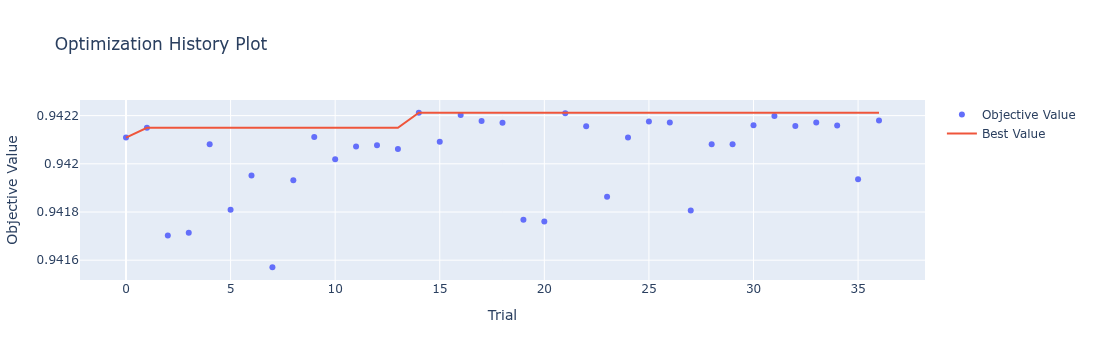

In [6]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except NameError:
    print("Optuna wasn't run")

## 5. Model Training & Multi-Seed Blending

In [7]:
seeds = setup.seed()
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.ones(len(X), dtype=bool)

models = []
eval_results = []
seed_scores = {}

base_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'metric_period': 5,
    'task_type': 'GPU' if setup.use_gpu() else 'CPU',
    'iterations': 2000,
    'verbose': False,
    **best_params
}

for current_seed in seeds:
    print(f'\n--- Training CatBoost across 5 Folds with Seed {current_seed} ---')
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    seed_oof = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = cb.CatBoostClassifier(**base_params, cat_features=cat_cols, random_seed=current_seed, early_stopping_rounds=100)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            verbose=False
        )
        
        val_pred_prob = model.predict_proba(X_val)
        seed_oof[val_idx] = val_pred_prob[:, 1]
        
        oof_probs[val_idx, 0] += val_pred_prob[:, 0] / len(seeds)
        oof_probs[val_idx, 1] += val_pred_prob[:, 1] / len(seeds)
        
        test_pred_prob = model.predict_proba(X_test)
        test_probs[:, 0] += test_pred_prob[:, 0] / (len(seeds) * 5)
        test_probs[:, 1] += test_pred_prob[:, 1] / (len(seeds) * 5)
        
        models.append(model)
        eval_results.append(model.get_evals_result())
        
        fold_auc = roc_auc_score(y_val, val_pred_prob[:, 1])
        print(f'Seed {current_seed} | Fold {fold+1} ROC AUC: {fold_auc:.6f}')
        
    seed_auc = roc_auc_score(y, seed_oof)
    seed_scores[current_seed] = seed_auc
    print(f'>>> Seed {current_seed} OOF ROC AUC: {seed_auc:.6f}')

print('\n==========================================')
for s, score in seed_scores.items():
    print(f'Seed {s:<5} OOF ROC AUC: {score:.6f}')
overall_auc = roc_auc_score(y, oof_probs[:, 1])
print('------------------------------------------')
print(f'Overall Multi-Seed OOF ROC AUC: {overall_auc:.6f}')
print('==========================================')


--- Training CatBoost across 5 Folds with Seed 10301 ---
Seed 10301 | Fold 1 ROC AUC: 0.940898


Seed 10301 | Fold 2 ROC AUC: 0.942485
Seed 10301 | Fold 3 ROC AUC: 0.942481
Seed 10301 | Fold 4 ROC AUC: 0.941493
Seed 10301 | Fold 5 ROC AUC: 0.943297
>>> Seed 10301 OOF ROC AUC: 0.942121

--- Training CatBoost across 5 Folds with Seed 42 ---
Seed 42 | Fold 1 ROC AUC: 0.940936
Seed 42 | Fold 2 ROC AUC: 0.941880


Seed 42 | Fold 3 ROC AUC: 0.943264
Seed 42 | Fold 4 ROC AUC: 0.942492
Seed 42 | Fold 5 ROC AUC: 0.942099
>>> Seed 42 OOF ROC AUC: 0.942129

--- Training CatBoost across 5 Folds with Seed 2026 ---
Seed 2026 | Fold 1 ROC AUC: 0.941615
Seed 2026 | Fold 2 ROC AUC: 0.941366
Seed 2026 | Fold 3 ROC AUC: 0.943539
Seed 2026 | Fold 4 ROC AUC: 0.942147
Seed 2026 | Fold 5 ROC AUC: 0.942191
>>> Seed 2026 OOF ROC AUC: 0.942168

--- Training CatBoost across 5 Folds with Seed 777 ---
Seed 777 | Fold 1 ROC AUC: 0.942707
Seed 777 | Fold 2 ROC AUC: 0.942498
Seed 777 | Fold 3 ROC AUC: 0.941466
Seed 777 | Fold 4 ROC AUC: 0.941505
Seed 777 | Fold 5 ROC AUC: 0.942336
>>> Seed 777 OOF ROC AUC: 0.942100

--- Training CatBoost across 5 Folds with Seed 888 ---
Seed 888 | Fold 1 ROC AUC: 0.941124
Seed 888 | Fold 2 ROC AUC: 0.941979
Seed 888 | Fold 3 ROC AUC: 0.943094


Seed 888 | Fold 4 ROC AUC: 0.942328
Seed 888 | Fold 5 ROC AUC: 0.942185
>>> Seed 888 OOF ROC AUC: 0.942136

Seed 10301 OOF ROC AUC: 0.942121
Seed 42    OOF ROC AUC: 0.942129
Seed 2026  OOF ROC AUC: 0.942168
Seed 777   OOF ROC AUC: 0.942100
Seed 888   OOF ROC AUC: 0.942136
------------------------------------------
Overall Multi-Seed OOF ROC AUC: 0.942330


## 6. Performance Visualization

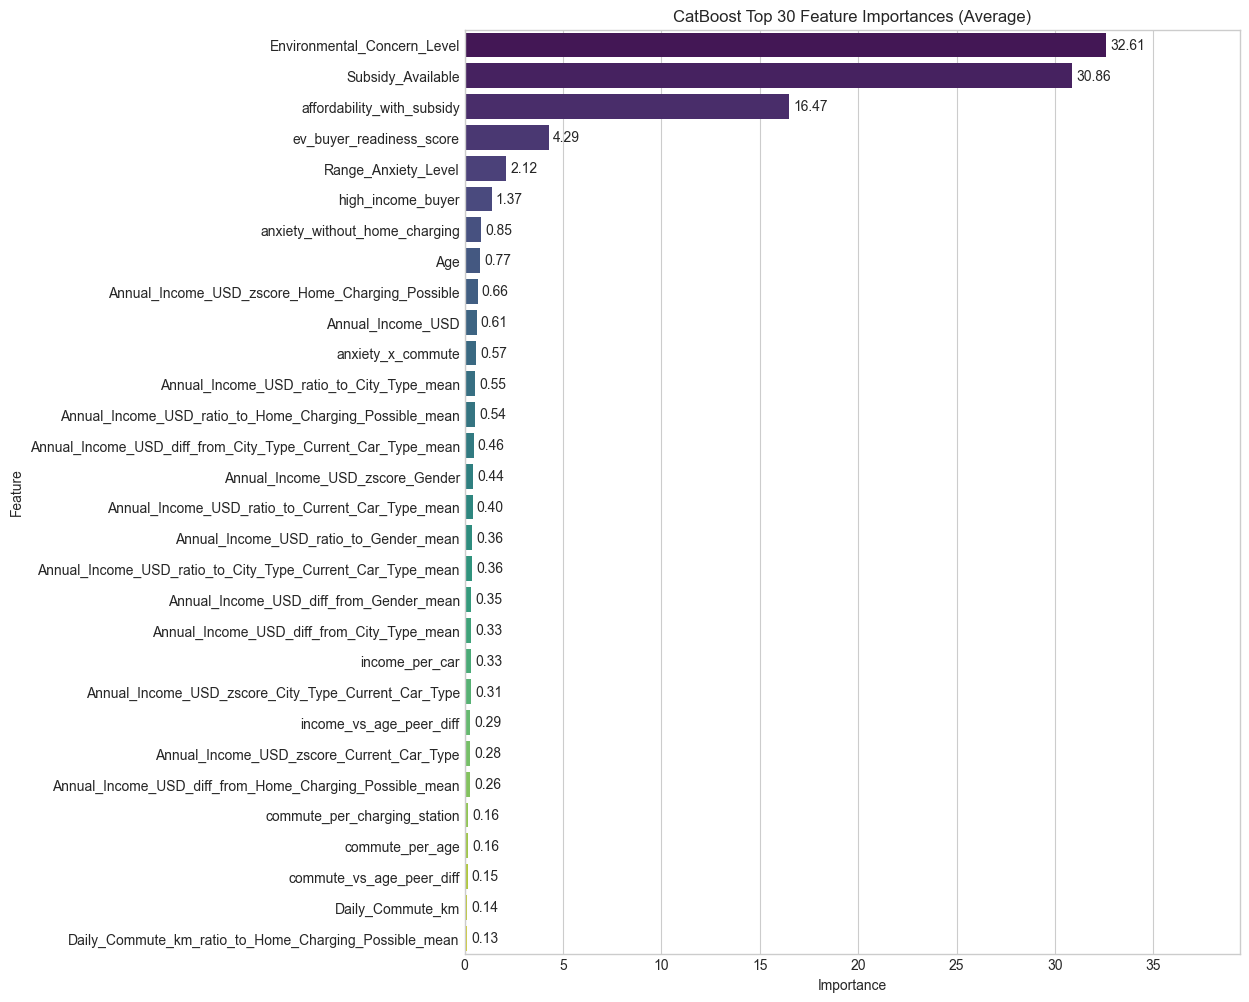

In [8]:
mviz = ModelVisualizer(model_name='CatBoost')
mviz.plot_feature_importance(models[:5], show_values=True)

<Figure size 800x600 with 0 Axes>

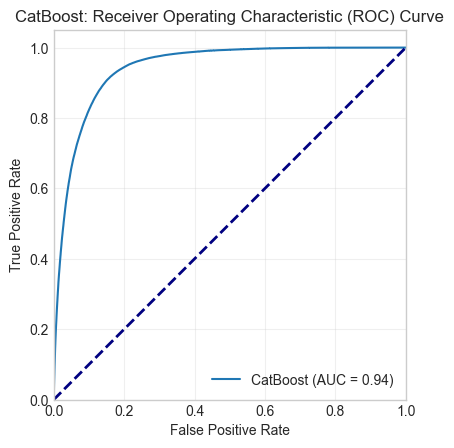

In [9]:
mviz.plot_roc_curve(y_true=y, y_score=oof_probs[:, 1])

Confusion matrix, without normalization


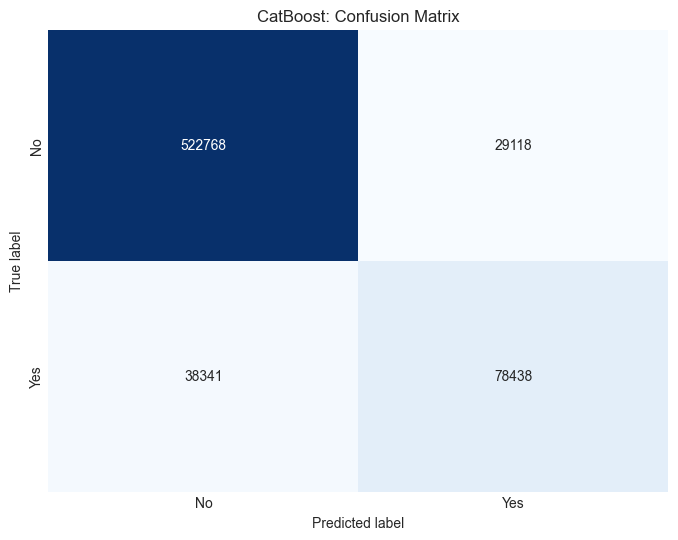

In [10]:
y_pred_class = (oof_probs[:, 1] >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y, y_pred=y_pred_class, classes=['No', 'Yes'])

## 7. Export Submission & Predictions

In [11]:
submission_df = setup.read_dataset('submission')
submission_df[TARGET] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print('Saved submission.csv successfully!')

setup.save_probabilities('catboost', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved submission.csv successfully!
Saved for ensembling:
 - predictions/catboost_oof_probs.csv
 - predictions/catboost_test_probs.csv
